In [1]:
import librosa
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import sys
import torch
import torchaudio as ta
import torch.nn.functional as F

import_path = Path.cwd().parent
os.sys.path.insert(0, str(import_path))
import feature_utils as futils
import utils
from configs import get_specgram_config
from plot_functions import plot_features

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graph_path = Path.cwd() / "graphs"
elbow_path = r"D:\clustering\clustering_outputs_4068/kmeans_curve_scores.npz"

## Load features from Slurm job

In [3]:
d_path = Path(r"D:\second_extraction")
files = sorted(d_path.rglob("*.npz"))

for path in files[0:3]:
    with np.load(path, allow_pickle=False) as z:
        print("Arrays in file:", z.files) # Keys list.
        for k in z.files:
            a = z[k]
            print(f" sample: {a.ravel()[:5]} with shape {a.shape}")

Arrays in file: ['feature', 'sr', 'source_path']
 sample: [-100. -100. -100. -100. -100.] with shape (1, 128, 33125)
 sample: [64000] with shape ()
 sample: ['/home/trh104/original_data/Aug_6229/6229.220802122000.wav'] with shape ()
Arrays in file: ['feature', 'sr', 'source_path']
 sample: [-100. -100. -100. -100. -100.] with shape (1, 128, 33125)
 sample: [64000] with shape ()
 sample: ['/home/trh104/original_data/Aug_6229/6229.220802124000.wav'] with shape ()
Arrays in file: ['feature', 'sr', 'source_path']
 sample: [-100. -100. -100. -100. -100.] with shape (1, 128, 33125)
 sample: [64000] with shape ()
 sample: ['/home/trh104/original_data/Aug_6229/6229.220802130000.wav'] with shape ()


In [4]:
d_path = Path(r"D:\second_extraction")
files = sorted(d_path.rglob("*.npz"))
files = files[0:10]
specgram_configs = get_specgram_config()
N_MELS = specgram_configs["n_mels"]
S, ids = futils.load_features_TxB(files, N_MELS)
print(S.shape)
# print(S[0:1, 0:128])

(331250, 128)


$S$ has shape $(T, B) = (T, 128)$ where T is the total number of time frames.

The index $t$ of $T$ represents the time. Each t represents 8 ms.

Each $t$ has a value in each mel band.

For $S(t, b) = S(1, 0:128)$ shows the magnitude of all 128 mel bands. 
$S(t, b) = S(1, 0:1)$ shows the magnutide of mel band $b=1$ at the time frame $t=1$.

$S(t , b)$ gives the log-mel power of mel band $b$ at time $t$.

### Crop to $\min(T)$

Gives feature matrix $S=(T, B)$ where $T=33121$ and $B=128$.

In [5]:
X = futils.build_feature_matrix_TxB(files, N_MELS, key="feature", crop_mode="left")
S = X["X_time_major"]
print(S.shape)

(10, 33125, 128)


## Flatten S

$S_{flat} = (N, T\cdot B)$.

In [6]:
# S = S.reshape(len(ids), -1)
print(S.shape)
S_flat = S.reshape(S.shape[0], -1)
print(S_flat.shape)

(10, 33125, 128)
(10, 4240000)


## Mel band center frequencies and bandwidth
- May want to sort away irrelevant mel bands.

In [7]:
sr = specgram_configs["sample_rate"]
f_min, f_max = specgram_configs["f_min"], specgram_configs["f_max"]

centers_hz = librosa.mel_frequencies(n_mels=N_MELS, fmin=f_min, fmax=f_max, htk=True)
edges_hz = librosa.mel_frequencies(n_mels=N_MELS + 2, fmin=f_min, fmax=f_max, htk=True)
bandwidths_hz = edges_hz[2:] - edges_hz[:-2]

In [8]:
# Highest center mel power is 32k (accords with Nyquist at 64k sample rate).
print(centers_hz[0:3]) # Center frequency of lowest mel bands in hz.
print(centers_hz[-3:]) # Center frequency of highest mel bands in hz.
print("\n")
print(edges_hz[0:4]) # Edge frequency of lowest mel bands in hz.
print(edges_hz[-4:]) # Edge frequency of highest mel bands in hz.
print("\n")
print(bandwidths_hz[0:3]) # Distance to neighboring mel bands.
print(bandwidths_hz[-3:])

[ 0.         21.51159261 43.68425466]
[30079.19137927 31025.06198737 32000.        ]


[ 0.         21.17308611 42.98660018 65.45991341]
[29203.59076818 30108.0926285  31039.95319707 32000.        ]


[42.98660018 44.2868273  45.62638274]
[1782.44824299 1836.36242889 1891.9073715 ]


In [9]:
# x = np.arange(len(centers_hz))
# fig, ax_left = plt.subplots(figsize=(7, 5))
# # Left y-axis: centers (Hz)
# line_centers, = ax_left.plot(x, centers_hz, color="royalblue", alpha=0.8, label="Center frequency (Hz)")
# ax_left.set_xlabel("Mel bin index")
# ax_left.set_ylabel("Center (Hz)")
# ax_left.set_yscale("log")
# # Right y-axis: bandwidths (Hz)
# ax_right = ax_left.twinx()
# line_bw, = ax_right.plot(x, bandwidths_hz, color="lightcoral", alpha=0.8, label="Bandwidth (Hz)")
# ax_right.set_ylabel("Bandwidth (Hz)")
# ax_right.set_yscale("log")

# lines = [line_centers, line_bw]
# labels = [l.get_label() for l in lines]
# ax_left.legend(lines, labels, loc="best")
# ax_left.grid(True, which="both", axis="both")
# fig.tight_layout()
# plt.show()

The hertz to log-mel function is

$mel(f) = 2595 \cdot \log_{10}(1+\frac{f}{700})$

and documented in: https://docs.pytorch.org/audio/0.7.0/_modules/torchaudio/functional.html

Since Ames et al. provide PEAK frequencies from $15.04 \pm 10.58$ to $30.25 \pm 1.99$ (ignoring the three Type F samples at low frequencies $\approx 2$ kHz), we want to include log-mel bins 50 to 128.

In [16]:
def hz_to_mel(f): return 2595 * np.log10(1 + f / 700)

def freq_to_melbin(f, fmin=0, fmax=32000, n_mels=128):
    m = hz_to_mel(f)
    mmin, mmax = hz_to_mel(fmin), hz_to_mel(fmax)
    return (m - mmin) / (mmax - mmin) * (n_mels - 1)

for f in [220, 1000, 1700, 2000, 3000, 3600, 4000, 5000, 10000, 15000, 20000, 32000]:
    print(f"{f/1000:5.2f} kHz → mel bin {freq_to_melbin(f):.1f}")

 0.22 kHz → mel bin 9.0
 1.00 kHz → mel bin 29.3
 1.70 kHz → mel bin 40.7
 2.00 kHz → mel bin 44.6
 3.00 kHz → mel bin 55.0
 3.60 kHz → mel bin 60.0
 4.00 kHz → mel bin 62.9
 5.00 kHz → mel bin 69.3
10.00 kHz → mel bin 90.1
15.00 kHz → mel bin 102.8
20.00 kHz → mel bin 111.9
32.00 kHz → mel bin 127.0


In [25]:
for f in [220, 3600, 5000]:
    print(freq_to_melbin(f, fmin=f_min, fmax=f_max, n_mels=N_MELS)) # = m.

9.029084779788711
59.97367996074872
69.2854985163131


## Downsampling
- Use average pooling.
- Need to convert back to linear spectrogram because $E(\log) \neq \log(E)$.

(33125, 128)
(33125, 88)
torch.Size([8000, 88])


c:\Users\Lindholm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


torch.Size([1, 8000, 88])


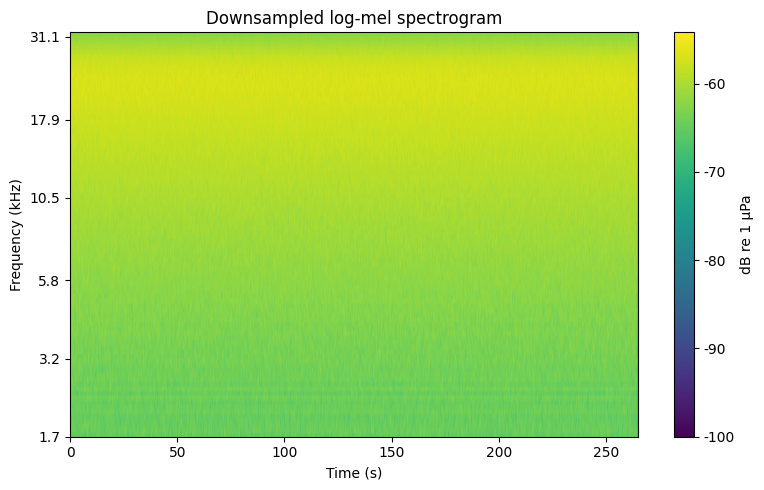

In [11]:
s1 = S[0]
original_frames = s1.shape[0]
print(s1.shape)
s1 = s1[:, 40:] # n_mels from 40 to 128?
print(s1.shape)
T_target = 8000 # 33124//4 = 8281
s1_ds = futils.downsample_time_avgpool_from_db(s1, T_target, ref=1.0)
print(s1_ds.shape)

transf = utils.PipelineSpecgram(specgram_config=specgram_configs).to(device).eval()
plot_features(s1_ds.unsqueeze(0), transf=transf, specgram_config=specgram_configs, path=graph_path / "s_ds_mel_scale.png"
              , title="Downsampled log-mel spectrogram", unit="freq", t_frames_original=original_frames, mel_idx_start=40, n_mels_full=128)
print(s1_ds.unsqueeze(0).shape)

torch.Size([33125, 128])
torch.Size([33125, 88])


(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'log-mel spectrogram'}, xlabel='Time (s)', ylabel='Mel bin'>)

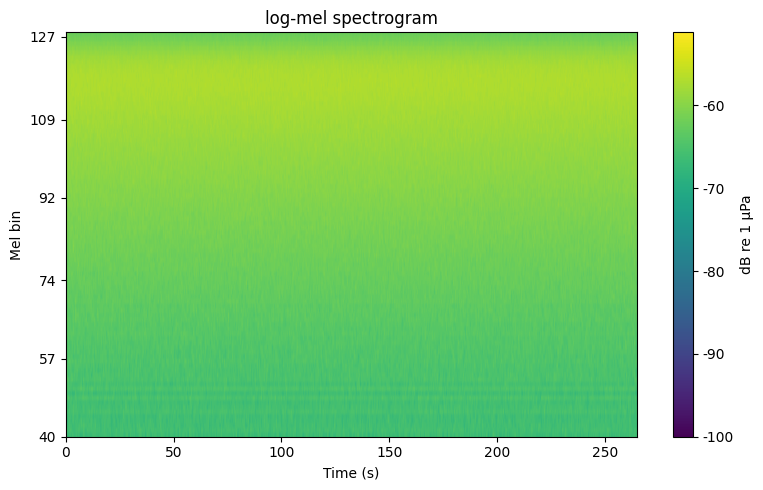

In [12]:
s2 = torch.as_tensor(S[0])
s2_orig = s2.shape[0]
print(s2.shape)
s2 = s2[:, 40:]
print(s2.shape)
plot_features(s2.unsqueeze(0), transf=transf, specgram_config=specgram_configs, path=graph_path / "s2_mel_scale.png", title="log-mel spectrogram"
              , unit="bins", t_frames_original=s2_orig, mel_idx_start=40, n_mels_full=128)

## k-means full set

In [13]:
d_path = Path(r"D:\clustering\clustering_outputs_4067/pca_kmeans_batches.npz")

In [14]:
with np.load(d_path, allow_pickle=False) as z:
    print("Arrays in file:", z.files) # Keys list.
    for k in z.files:
        a = z[k]
        print(f" sample: {a.ravel()[:5]} with shape {a.shape}")

Arrays in file: ['used_paths', 'scaler_mean', 'scaler_scale', 'ipca_components', 'ipca_mean', 'ipca_explained_variance', 'ipca_explained_variance_ratio', 'kmeans_centers', 'kmeans_inertia', 'silhouette']
 sample: ['/home/trh104/logmel_outputs_9979/Aug_6229/6229.220802122000.npz'
 '/home/trh104/logmel_outputs_9979/Aug_6229/6229.220802124000.npz'
 '/home/trh104/logmel_outputs_9979/Aug_6229/6229.220802130000.npz'
 '/home/trh104/logmel_outputs_9979/Aug_6229/6229.220802132000.npz'
 '/home/trh104/logmel_outputs_9979/Aug_6229/6229.220802134000.npz'] with shape (12099,)
 sample: [82.46901  82.62873  82.167175 81.80142  81.58365 ] with shape (704000,)
 sample: [12.790043 12.737333 12.706472 12.657948 12.626381] with shape (704000,)
 sample: [0.00113995 0.00114128 0.00114207 0.00114377 0.00114508] with shape (256, 704000)
 sample: [-1.7530279e-08  5.5085567e-09  1.3758662e-09  3.1524026e-09
  4.5918753e-09] with shape (704000,)
 sample: [606587.7     37713.957   20177.898    6315.5327   4593.248

In [15]:
with np.load(d_path, allow_pickle=False) as z:
    used_paths = z["used_paths"] # (N_files,)
    scaler_mean = z["scaler_mean"] # (D,)
    scaler_scale = z["scaler_scale"] # (D,)
    ipca_components = z["ipca_components"] # (n_components, D) == (256, D)
    ipca_mean = z["ipca_mean"] # (D,)
    ipca_explained_variance = z["ipca_explained_variance"] # (n_components,)
    ipca_explained_variance_ratio = z["ipca_explained_variance_ratio"] # (n_components,)
    kmeans_centers = z["kmeans_centers"] # (k, n_components)
    kmeans_inertia = float(z["kmeans_inertia"].item()) # scalar
    silhouette = float(z["silhouette"].item()) # scalar

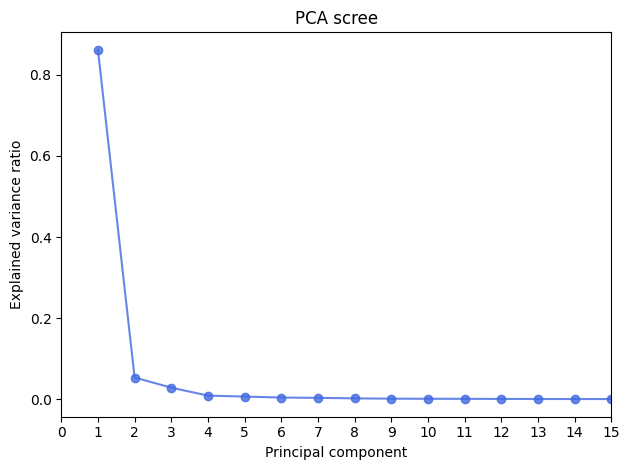

In [16]:
fig1, ax1 = plt.subplots()
ax1.plot(np.arange(1, len(ipca_explained_variance_ratio)+1), ipca_explained_variance_ratio, color="royalblue", alpha=0.8, marker='o')
ax1.set_xlim(0, 15)
ax1.set_xlabel("Principal component")
ax1.xaxis.set_major_locator(plt.MultipleLocator(1))
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("PCA scree")
fig1.tight_layout()
fig1.savefig(graph_path / "pca_scree.png", dpi=300)
plt.show()

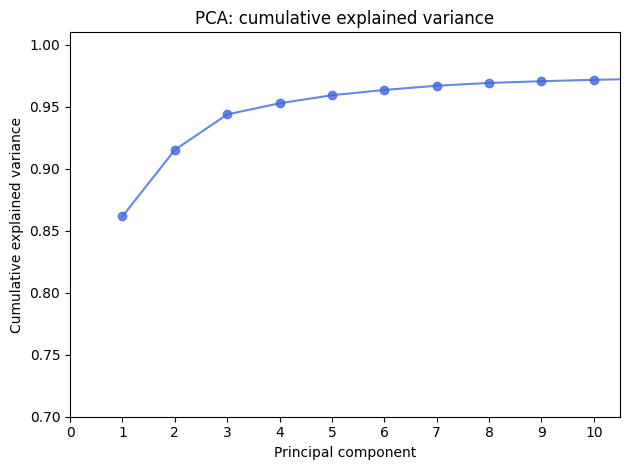

In [17]:
cum = np.cumsum(ipca_explained_variance_ratio)
fig2, ax2 = plt.subplots()
ax2.plot(np.arange(1, len(cum)+1), cum, color="royalblue", alpha=0.8, marker='o')
ax2.set_xlim(0, 10.5)
ax2.set_ylim(0.7, 1.01)
ax2.set_xlabel("Principal component")
ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("PCA: cumulative explained variance")
fig2.tight_layout()
fig2.savefig(graph_path / "pca_cumulative.png", dpi=300)

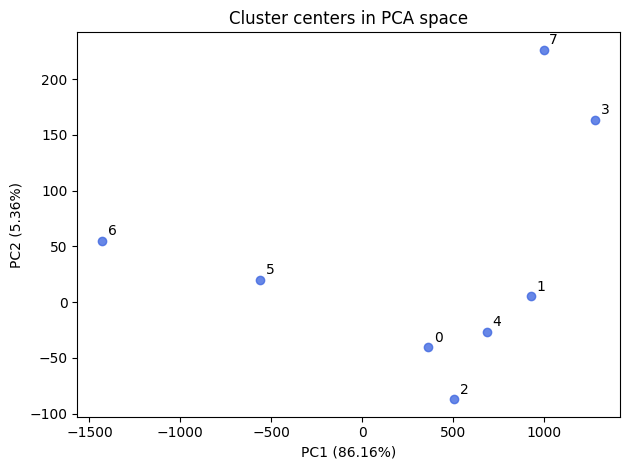

In [18]:
fig3, ax3 = plt.subplots()
x, y = kmeans_centers[:, 0], kmeans_centers[:, 1]
ax3.scatter(x, y, color="royalblue", alpha=0.8)
for i, (xi, yi) in enumerate(zip(x, y)):
    ax3.annotate(str(i), (xi, yi), xytext=(4, 4), textcoords="offset points")
ax3.set_xlabel(f"PC1 ({ipca_explained_variance_ratio[0]:.2%})")
ax3.set_ylabel(f"PC2 ({ipca_explained_variance_ratio[1]:.2%})")
ax3.set_title("Cluster centers in PCA space")
fig3.tight_layout()
fig3.savefig(graph_path / "kmeans_centers_pc1_pc2.png", dpi=160)

## Elbow method

Arrays in file: ['used_paths', 'inertias', 'silhouettes', 'n_components_kept']
n_components_kept (single value): 3
Suggested k by elbow: 7
Suggested k by silhouette: 2


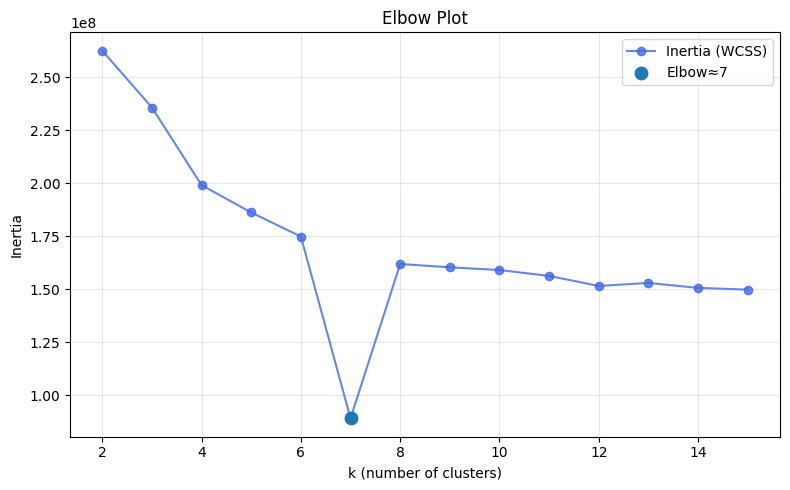

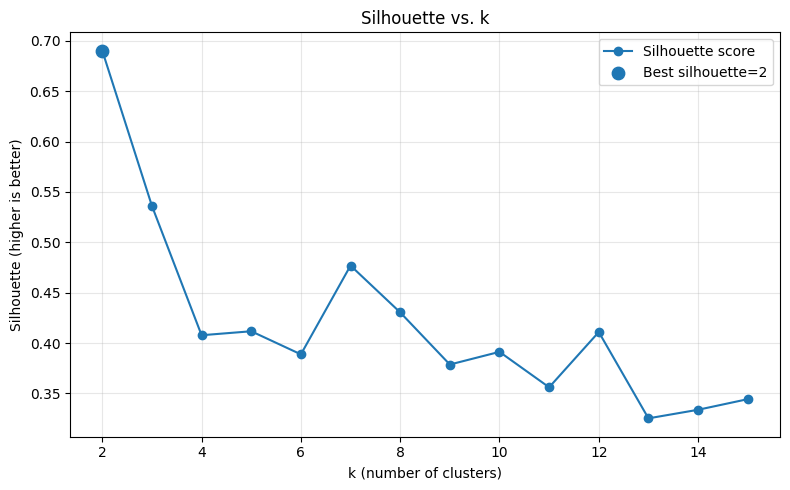

In [19]:
with np.load(elbow_path, allow_pickle=False) as z:
    keys = list(z.files)
    print("Arrays in file:", keys)
    inertias = z["inertias"]          # shape (num_k,)
    silhouettes = z["silhouettes"]    # shape (num_k,)
    ncomp = z.get("n_components_kept", None)  # optional, shape (num_k,) or scalar
    k_values = z.get("k_values", None)        # optional

# Build the x-axis (k)
if k_values is not None:
    k = np.asarray(k_values).ravel()
else:
    # Fallback: assume you tested k starting at 2 with step 1
    num_k = len(inertias)
    k = np.arange(2, 2 + num_k)

# Quick sanity checks
assert len(inertias) == len(k) == len(silhouettes), "inertias/silhouettes length must match k."

# Heuristics for suggested k
best_k_sil = k[np.argmax(silhouettes)]
# (Optional) crude elbow via first differences
diffs = np.diff(inertias)
elbow_idx = np.argmin(np.diff(diffs)) + 2 if len(diffs) >= 2 else np.argmin(inertias)
best_k_elbow = k[elbow_idx]

# --- Plot Elbow & Silhouette ---
plt.figure(figsize=(8, 5))
plt.plot(k, inertias, marker="o", color="royalblue", alpha=0.8, label="Inertia (WCSS)")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.grid(True, alpha=0.3)
plt.scatter([best_k_elbow], [inertias[np.where(k==best_k_elbow)[0][0]]], s=80, zorder=3, label=f"Elbow≈{best_k_elbow}")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(graph_path / "elbow_plot.png", dpi=150)

plt.figure(figsize=(8, 5))
plt.plot(k, silhouettes, marker="o", label="Silhouette score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette (higher is better)")
plt.title("Silhouette vs. k")
plt.grid(True, alpha=0.3)
plt.scatter([best_k_sil], [np.max(silhouettes)], s=80, zorder=3, label=f"Best silhouette={best_k_sil}")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(graph_path / "silhouette_plot.png", dpi=150)

# --- Plot n_components_kept if it matches per-k ---
if ncomp is not None:
    ncomp = np.asarray(ncomp).ravel()
    if len(ncomp) == len(k):
        plt.figure(figsize=(8, 5))
        plt.plot(k, ncomp, marker="o")
        plt.xlabel("k (number of clusters)")
        plt.ylabel("n_components_kept")
        plt.title("PCA components kept vs. k")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(graph_path /"n_components_kept_vs_k.png", dpi=150)
    elif ncomp.size == 1:
        print(f"n_components_kept (single value): {int(ncomp.item())}")
    else:
        print("n_components_kept present but not aligned per-k; skipping plot.")

print(f"Suggested k by elbow: {best_k_elbow}")
print(f"Suggested k by silhouette: {best_k_sil}")